<h1>I. Preprocesamiento de los Datos</h1>
<h2>Datos Anómalos (outliers)</h2>
Supongamos que nos piden analizar el ingreso mensual de un conjunto de 500 personas, sin embargo dentro de esta muestra se encuentra una persona <span style="color:red">atípica</span> (la persona más rica del país). Entonces si nosotros calcularamos algo tan sencillo como el promedio del ingreso, es claro saber que esta persona que gana miles o millones de dolares mensualmente afectaria el promedio de la muestra que no sería representativo y podría causar que obtengamos conclusiones erroneas en nuestro análisis. Además si estamos haciendo un modelo de aprendizaje automático este dato podría sesgar el modelo.
En este ejemplo usaremos los diagramas de caja para detectar valores anomalos en los datos.

<h3>Diagramas de caja o diagramas de bigotes</h3>
Objetivo:mostrar la distribución de los datos

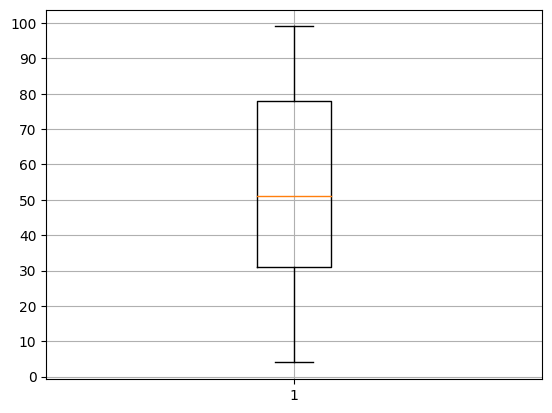

In [1]:
import numpy as np
import matplotlib.pyplot as plt
edades=np.array([4,17,29,33,50,51,61,71,85,92,99])
#Configurar marcar de medicion
plt.yticks(np.arange(0,110,10))
#activar malla
plt.grid(True)
plt.boxplot(edades)
plt.show()

Elementos del diagrama de cajas:<br/>
<ul>
    <li>El bigote inferior es el valor mínimo del conjunto de datos</li>
    <li>El bigote superior es el valor máximo</li>
    <li>La <span style="color:red">mediana</span> esta marcada en color anaranjado</span></li>
    <li>El borde inferior de la caja es el <span style="color:red">1er quartil</span></li>
    <li>La mediana es el 2o quartil</li>
    <li>El borde superior de la caja es el <span style="color:red">3er quartil</span></li>
</ul>
Veamos que sucede si agregamos varios valores mínimos

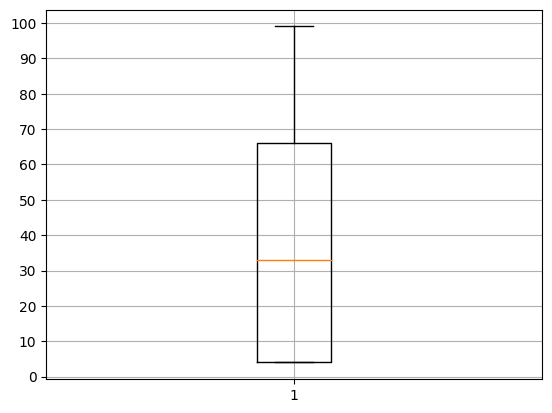

In [2]:
edades4=np.array([4,4,4,4,4,17,29,33,50,51,61,71,85,92,99])
plt.yticks(np.arange(0,110,10))
plt.grid(True)
plt.boxplot(edades4)
plt.show()

Veamos como se obtienen estos valores para crear el diagrama de cajas

In [3]:
(np.min(edades),np.quantile(edades,0.25),np.median(edades),np.quantile(edades,0.75),np.max(edades))

(4, 31.0, 51.0, 78.0, 99)

<h3>Datos anomalos/atípicos/outliers<br/>Prueba de Tukey</h3>

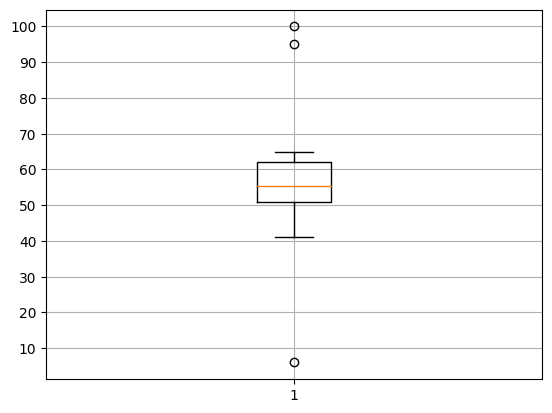

In [4]:
edades=np.array([6,
                41,51,51,52,54,57,60,61,65,
                95,100])
plt.yticks(np.arange(0,110,10))
plt.grid(True)
plt.boxplot(edades)
plt.show()

<ul>
    <li>Notemos que ahora los bigotes del boxplot no marcan el verdadero mínimo y máximo de los datos</li>
    <li>En función de la <span style="color:red">prueba de Tukey</span> 6,95 y 100 se consideraron como valores atípicos</li>
    <li>Efectivamente estos valores estan "muy lejos" de la <span style="color:red">mediana</span></li>
    <li>Pero lejos es un termino relativo, tendriamos que usar un método estándar para hacer esta afirmación.</li>
    <li>Python hace uso de manera automática de la prueba de Tukey suponiendo que los datos tienen una <span style="color:red">distribución normal</span></li>
</ul>

<h3>Regla empírica de la distribución normal 68-95-99.7</h3>
<img src="empirical_rule.jpg" width="500px" style="margin:0 auto;"/>

Supongamos que estamos revisando la distribución de los datos de altura de las personas y que la media &mu; es de 1.70 con una desviación estándar &sigma; de &plusmn; 5 cm<br/>
La regla empírica de la distribución normal nos dice que:
<ul>
    <li style="background-color:#DEFBAA">Esto implicaría que el <b>68%</b> de los datos deberian estar dentro del rango [&mu;-&sigma;=1.65,1.75=&mu;+&sigma;]</li>
    <li style="background-color:#aaFFFF">Que el <b>95%</b> de los datos deberian estar dentro del rango [&mu;-2&sigma;=1.6,1.8=&mu;+2&sigma;]</li>
    <li style="background-color:#ffaaff">Que el <b>99.7%</b> de los datos deberian estar dentro del rango [&mu;-3&sigma;=1.55,1.85=&mu;+3&sigma;]</li>
    Casos raros, es dificil encontrar personas muy bajitas o demasiado altas, dependiendo obviamente de la población. Estos serían nuestros datos anómalos, atípicos u outliers.
</ul>

Pero también es cierto que no todas las variables tienen una distribución normal, lo cual representa una desventaja para el método de Tukey al asumir que nuestros datos tienen esta distribución. Sin embargo es muy utilizado pues hay muchas variables que siguen esta distribución.Por eso es importante graficar nuestros datos para determinar que distribución siguen e incluso realizar pruebas estadísticas formales.<br/>
La regla de Tukey primero calcula el rango intercuartil
<h3>Rango intercuartílico para detectar outliers</h3>
<img src="rango_intercuartil.png" width="720px" style="margin:0 auto;"/>
<ul>
    <li>El rango intercuartil IQR se obtiene como <b>Q3-Q1</b> </li>
    <li>Los bigotes quedan en <b>Q1-1.5IQR</b> y <b>Q3+1.5IQR</b> al ver que la mayoría de los datos caen en este rango asumiendo una distribución normal</li>
    <li>Cualquier dato ubicado muy a la izquierda o muy a la derecha se asume como atípico o anómalo</li>
    <li>La importancia de la prueba de Tukey es que permite detectar de manera rápida outliers, los cuales de no eliminarse o tratarse pueden afectadar o sesgar las conclusiones obtenidas del modelado de datos o el entrenamiento de Machine Learning.</li>
</ul>

Existen técnicas estadísticas más formales para detectar outliers que dependen del dominio de los datos y del objetivo del modelo que usaremos.
<h3>Ejemplo de detección de outliers</h3>
Usaremos un archivo que contiene la longitud de los 141 rios principales de América del Norte, fuente almanaque mundial de 1975

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
Rios=pd.read_csv("Rios.csv")
Rios.head(10)

,Rio,Millas
0,1,735
1,2,320
2,3,325
3,4,392
4,5,524
5,6,450
6,7,1459
7,8,135
8,9,465
9,10,600


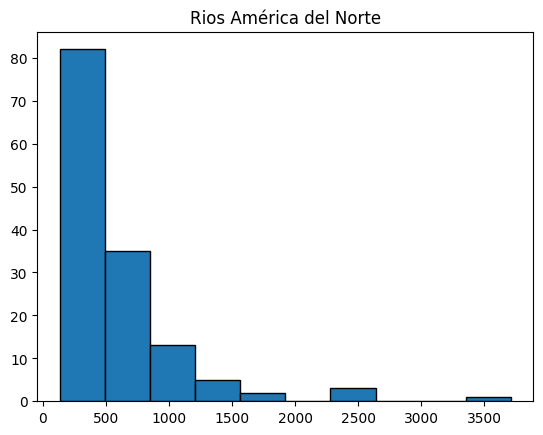

In [6]:
plt.title("Rios América del Norte")
plt.hist(Rios["Millas"],edgecolor="black",linewidth=1)
plt.show()

<h4>Diagrama de cajas o diagrama de bigotes</h4>

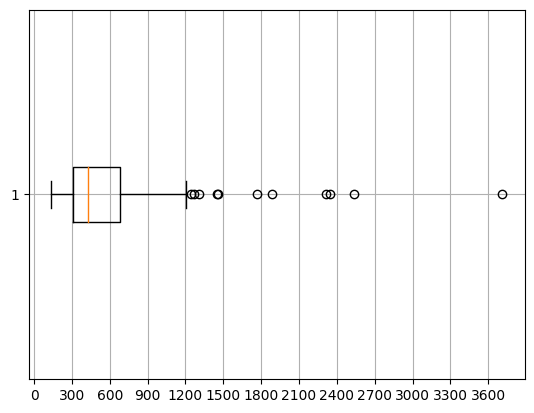

In [7]:
plt.boxplot(Rios["Millas"],vert=False)
plt.grid(True)
plt.xticks(np.arange(0,3900,300))
plt.show()

Obtenemos los valores del diagrama de cajas

In [8]:
Q1=Rios["Millas"].quantile(0.25)
print("Primer cuartil:\t\t",Q1)
mediana=Rios["Millas"].median()
print("Mediana:\t\t",mediana)
Q3=Rios["Millas"].quantile(0.75)
print("Tercer cuartil:\t\t",Q3)
IQR=Q3-Q1
print("Rango intercuartil:\t",IQR)
minimo=Rios["Millas"].min()
print("Valor mínimo:\t\t",minimo)
maximo=Rios["Millas"].max()
print("Valor máximo:\t\t",maximo)

Primer cuartil:		 310.0
Mediana:		 425.0
Tercer cuartil:		 680.0
Rango intercuartil:	 370.0
Valor mínimo:		 135
Valor máximo:		 3710


Obtenemos los valores del bigote inferior y del superior

In [9]:
BI=Q1-1.5*IQR
BS=Q3+1.5*IQR
print("Bigote inferior:\t",BI)
print("Bigote superior:\t",BS)

Bigote inferior:	 -245.0
Bigote superior:	 1235.0


<b>*NOTA:</b>
<ul>
    <li>Si el valor del bigote inferior es menor que el valor mínimo, se toma el valor mínimo</li>
    <li>Si el valor del bigote superior es mayor que el valor máximo, se toma el valor máximo</li>
    <li>Se consideran como outliers todos los valores que queden fuera del rango formado por los bigotes inferior y superior</li>
</ul>

In [10]:
ubicacion_outliers=(Rios["Millas"]<BI) | (Rios["Millas"]>BS)
print("Ubicacion outliers:\n",ubicacion_outliers)

Ubicacion outliers:
 0      False
1      False
2      False
3      False
4      False
       ...  
136    False
137    False
138    False
139    False
140     True
Name: Millas, Length: 141, dtype: bool


Obtenemos los valores de los outliers

In [11]:
outliers=Rios[ubicacion_outliers]
outliers

,Rio,Millas
6,7,1459
22,23,1450
24,25,1243
65,66,2348
67,68,3710
68,69,2315
69,70,2533
82,83,1306
97,98,1270
100,101,1885


Nos quedamos solo con los valores que no son atipicos

In [12]:
ubicacion_sin_out=(Rios["Millas"]>=BI) & (Rios["Millas"]<=BS)
sin_outliers=Rios[ubicacion_sin_out]
sin_outliers

,Rio,Millas
0,1,735
1,2,320
2,3,325
3,4,392
4,5,524
...,...,...
135,136,500
136,137,720
137,138,270
138,139,430


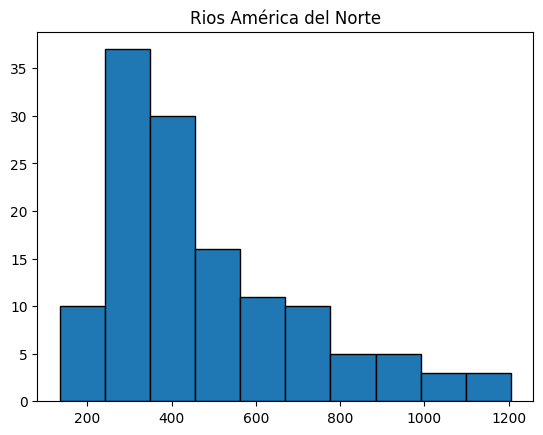

In [13]:
plt.title("Rios América del Norte")
plt.hist(sin_outliers["Millas"],edgecolor="black",linewidth=1)
plt.show()

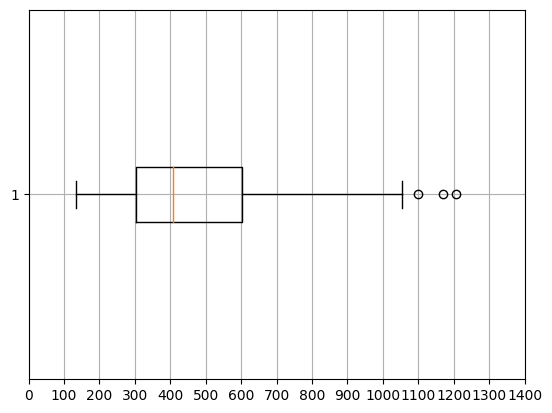

In [14]:
plt.boxplot(sin_outliers["Millas"],vert=False)
plt.grid(True)
plt.xticks(np.arange(0,1500,100))
plt.show()

Al volver a graficar la distribución y el diagrama de cajas, se marcan otros 3 valores extremos, sin embargo estos no son outliers del conjunto original y eliminarlos solo haría que los datos adopten poco a poco una distribución cercana a la normal.

Además de eliminar los <span style="color:red">outliers</span> en algunas ocasiones es necesario obtener medidas de tendencia central más robustas que la <span style="color:red">media aritmética</span> pues esta podria verse afectada por la presencia de outliers si estos no se eliminan.

<H3>Alternativas a la media</H3>
Si calculamos la mediana para el conjunto original y el conjunto sin outliers

In [33]:
print("Mediana original\t",Rios["Millas"].median())
print("Mediana sin outliers\t",sin_outliers["Millas"].median())
print("Media arirmetica original:\t",Rios["Millas"].mean())
print("Media arirmetica sin outliers:\t",sin_outliers["Millas"].mean())

Mediana original	 425.0
Mediana sin outliers	 408.5
Media arirmetica original:	 591.1843971631206
Media arirmetica sin outliers:	 477.44615384615383


Notemos que la variación de las medianas es mucho menor a la variación de las medias por eso decimos que es una medida más robusta. Veamos otras alternativas:
<h5>La media recortada (trimming)</h5>
"Desecha" los valores extremos. Es decir, elimina del análisis una fracción de los datos extremos (por ejemplo 20%,10%) y calcula la media del nuevo conjunto de datos.

In [19]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [38]:
from scipy import stats
print("Media recortada original:\t",stats.trim_mean(Rios['Millas'], 0.1))
print("Media recortada sin outliers:\t",stats.trim_mean(sin_outliers['Millas'], .1))

Media recortada original:	 490.94690265486724
Media recortada sin outliers:	 445.5576923076923


para que podamos especificar un porcentaje diferente en cada extremo usamos <span style="color:green">trimmed_mean</span>

In [45]:
print("Media recortada original:\t",stats.mstats.trimmed_mean(Rios['Millas'], (0,0.09)))
print("Media recortada sin outliers:\t",stats.mstats.trimmed_mean(sin_outliers['Millas'], (0,.09)))

Media recortada original:	 471.8062015503876
Media recortada sin outliers:	 427.92436974789916


<h5>La media winsorizada</h5>
Progresivamente reemplaza un porcentaje de los valores extremos (por ejemplo 20%, 10%) por otros menos extremos.

In [35]:
import numpy as np
from scipy.stats.mstats import winsorize
awin=winsorize(Rios["Millas"], limits=[0, 0.2])
soutwin=winsorize(sin_outliers["Millas"], limits=[0, 0.2])
print("media windsorizada original:\t",awin.mean())
print("media windsorizada sin outliers:",soutwin.mean())

media windsorizada original:	 472.36170212765956
media windsorizada sin outliers: 435.2153846153846
